In [339]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.model_selection import train_test_split

In [340]:
FAST_MODE = True
RANDOM_STATE = 42
TOP_K = 10

if FAST_MODE:
    MAX_USERS_EVAL = 300
    MF_DIM = 20
    SGD_EPOCHS = 10
    ALS_ITERS = 8
    TOP_M = 80
else:
    MAX_USERS_EVAL = None
    MF_DIM = 50
    SGD_EPOCHS = 25
    ALS_ITERS = 15
    TOP_M = 200

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [341]:
ratings_cols = ["user_id", "item_id", "rating", "timestamp"]
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=ratings_cols,
    encoding="latin-1"
)

item_cols = [
    "item_id", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

items = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    names=item_cols,
    encoding="latin-1"
)

print("Ratings shape:", ratings.shape)
print("Items shape:", items.shape)
ratings.head()

Ratings shape: (100000, 4)
Items shape: (1682, 24)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [342]:
train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (80000, 4)
Test shape: (20000, 4)


In [343]:
test_relevant = test_df[test_df["rating"] >= 4].copy()

train_items_by_user = train_df.groupby("user_id")["item_id"].apply(set).to_dict()
relevant_items_by_user = test_relevant.groupby("user_id")["item_id"].apply(set).to_dict()

all_items = set(items["item_id"].unique())
all_users = sorted(ratings["user_id"].unique())

print("Número total de users:", len(all_users))
print("Número total de items:", len(all_items))
print("Users com itens relevantes no teste:", len(relevant_items_by_user))

Número total de users: 943
Número total de items: 1682
Users com itens relevantes no teste: 920


1. Candidate generation

In [344]:
def get_candidates(user_id, all_items, train_items_by_user):
    seen_items = train_items_by_user.get(user_id, set())
    return list(all_items - seen_items)

Popularity baseline

In [345]:
item_popularity = train_df.groupby("item_id").size().to_dict()

def popularity_score(item_id):
    return item_popularity.get(item_id, 0)

def recommend_popularity(user_id, k=10):
    candidates = get_candidates(user_id, all_items, train_items_by_user)
    ranked_items = sorted(
        candidates,
        key=lambda item_id: popularity_score(item_id),
        reverse=True
    )
    return ranked_items[:k]

Métricas Recall@10 e NDCG@10

In [346]:
def recall_at_k(recommended, relevant, k=10):
    if not relevant:
        return None
    
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / len(relevant)


def dcg_at_k(recommended, relevant, k=10):
    dcg = 0.0
    for idx, item_id in enumerate(recommended[:k], start=1):
        if item_id in relevant:
            dcg += 1 / math.log2(idx + 1)
    return dcg

def ndcg_at_k(recommended, relevant, k=10):
    if not relevant:
        return None
    
    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
    
    if idcg == 0:
        return 0.0
    
    return dcg_at_k(recommended, relevant, k) / idcg

Avaliar o popularity baseline

In [347]:
eligible_users = [u for u in all_users if u in relevant_items_by_user]

if FAST_MODE and MAX_USERS_EVAL is not None:
    eligible_users = eligible_users[:MAX_USERS_EVAL]

results = []

for user_id in eligible_users:
    recommended = recommend_popularity(user_id, k=TOP_K)
    relevant = relevant_items_by_user[user_id]

    recall = recall_at_k(recommended, relevant, k=TOP_K)
    ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)

    results.append({
        "user_id": user_id,
        "method": "popularity",
        "recall@10": recall,
        "ndcg@10": ndcg
    })

results_df = pd.DataFrame(results)
results_df.head()

,user_id,method,recall@10,ndcg@10
0,1,popularity,0.117647,0.538431
1,2,popularity,0.000000,0.000000
2,3,popularity,0.333333,0.234639
3,4,popularity,0.500000,0.613147
4,5,popularity,0.083333,0.066254


Média final do baseline

In [348]:
results_df[["recall@10", "ndcg@10"]].mean()

recall@10    0.138766
ndcg@10      0.178276
dtype: float64

Ver recomendações de exemplo

In [349]:
example_user = eligible_users[0]
example_recs = recommend_popularity(example_user, k=10)

print("User:", example_user)
print("Top-10 item ids:", example_recs)

items[items["item_id"].isin(example_recs)][["item_id", "title"]]

User: 1
Top-10 item ids: [np.int64(100), np.int64(181), np.int64(258), np.int64(288), np.int64(286), np.int64(294), np.int64(300), np.int64(1), np.int64(237), np.int64(405)]


,item_id,title
0,1,Toy Story (1995)
99,100,Fargo (1996)
180,181,Return of the Jedi (1983)
236,237,Jerry Maguire (1996)
257,258,Contact (1997)
285,286,"English Patient, The (1996)"
287,288,Scream (1996)
293,294,Liar Liar (1997)
299,300,Air Force One (1997)
404,405,Mission: Impossible (1996)


Vetores de genero

In [350]:
genre_columns = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

item_genres = items.set_index("item_id")[genre_columns].astype(float)

item_genre_vectors = {
    item_id: item_genres.loc[item_id].values
    for item_id in item_genres.index
}

Funções auxiliares para similaridade e diversidade

In [351]:
def cosine_similarity(vec_a, vec_b):
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    
    if norm_a == 0 or norm_b == 0:
        return 0.0
    
    return float(np.dot(vec_a, vec_b) / (norm_a * norm_b))



def diversity_at_k(recommended, item_genre_vectors, k=10):
    recs = recommended[:k]
    
    if len(recs) < 2:
        return 0.0
    
    pairwise_distances = []
    
    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            item_i = recs[i]
            item_j = recs[j]
            
            vec_i = item_genre_vectors.get(item_i)
            vec_j = item_genre_vectors.get(item_j)
            
            if vec_i is None or vec_j is None:
                continue
            
            sim = cosine_similarity(vec_i, vec_j)
            dist = 1.0 - sim
            pairwise_distances.append(dist)
    
    if not pairwise_distances:
        return 0.0
    
    return float(np.mean(pairwise_distances))

Reavaliar o popularity baseline com Diversity@10

In [352]:
results = []

for user_id in eligible_users:
    recommended = recommend_popularity(user_id, k=TOP_K)
    relevant = relevant_items_by_user[user_id]

    recall = recall_at_k(recommended, relevant, k=TOP_K)
    ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
    diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

    results.append({
        "user_id": user_id,
        "method": "popularity",
        "top_k": recommended,
        "recall@10": recall,
        "ndcg@10": ndcg,
        "diversity@10": diversity
    })

results_df = pd.DataFrame(results)
results_df.head()

,user_id,method,top_k,recall@10,ndcg@10,diversity@10
0,1,popularity,"[100, 181, 258, 288, 286, 294, 300, 1, 237, 405]",0.117647,0.538431,0.840930
1,2,popularity,"[181, 121, 98, 56, 7, 174, 117, 222, 172, 405]",0.000000,0.000000,0.612257
2,3,popularity,"[50, 100, 181, 286, 294, 1, 121, 127, 98, 56]",0.333333,0.234639,0.758890
3,4,popularity,"[50, 100, 181, 286, 1, 121, 127, 98, 56, 7]",0.500000,0.613147,0.699154
4,5,popularity,"[258, 288, 286, 294, 300, 127, 56, 7, 174, 237]",0.083333,0.066254,0.783726


Ver médias das 3 métricas

In [353]:
results_df[["recall@10", "ndcg@10", "diversity@10"]].mean()

recall@10       0.138766
ndcg@10         0.178276
diversity@10    0.752100
dtype: float64

Guardar logs em JSONL

In [354]:
os.makedirs("logs", exist_ok=True)

with open("logs/popularity_eval.jsonl", "w", encoding="utf-8") as f:
    for row in results:
        log_entry = {
            "user_id": int(row["user_id"]),
            "method": row["method"],
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "k": TOP_K
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/popularity_eval.jsonl")

Ficheiro criado: logs/popularity_eval.jsonl


Confirmar que o log foi escrito

In [355]:
with open("logs/popularity_eval.jsonl", "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().strip())

{"user_id": 1, "method": "popularity", "top_k": [100, 181, 258, 288, 286, 294, 300, 1, 237, 405], "metrics": {"recall@10": 0.11764705882352941, "ndcg@10": 0.5384313152574521, "diversity@10": 0.8409300270383773}, "hyperparameters": {"k": 10}}
{"user_id": 2, "method": "popularity", "top_k": [181, 121, 98, 56, 7, 174, 117, 222, 172, 405], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.6122570494623688}, "hyperparameters": {"k": 10}}
{"user_id": 3, "method": "popularity", "top_k": [50, 100, 181, 286, 294, 1, 121, 127, 98, 56], "metrics": {"recall@10": 0.3333333333333333, "ndcg@10": 0.23463936301137822, "diversity@10": 0.7588895208815484}, "hyperparameters": {"k": 10}}


Preparar índices para o MF-SGD

In [356]:
unique_user_ids = sorted(ratings["user_id"].unique())
unique_item_ids = sorted(ratings["item_id"].unique())

user_to_index = {user_id: idx for idx, user_id in enumerate(unique_user_ids)}
item_to_index = {item_id: idx for idx, item_id in enumerate(unique_item_ids)}

index_to_user = {idx: user_id for user_id, idx in user_to_index.items()}
index_to_item = {idx: item_id for item_id, idx in item_to_index.items()}

n_users = len(unique_user_ids)
n_items = len(unique_item_ids)

print("n_users =", n_users)
print("n_items =", n_items)

n_users = 943
n_items = 1682


Converter train/test para índices internos

In [357]:
train_data = [
    (
        user_to_index[row.user_id],
        item_to_index[row.item_id],
        float(row.rating)
    )
    for row in train_df.itertuples(index=False)
]

test_data = [
    (
        user_to_index[row.user_id],
        item_to_index[row.item_id],
        float(row.rating)
    )
    for row in test_df.itertuples(index=False)
]

print("Train tuples:", len(train_data))
print("Test tuples:", len(test_data))
print("Exemplo:", train_data[:5])

Train tuples: 80000
Test tuples: 20000
Exemplo: [(806, 1410, 1.0), (473, 658, 5.0), (462, 267, 4.0), (138, 285, 4.0), (620, 750, 4.0)]


## MF-SGD

Função de treino MF-SGD

In [358]:
def train_mf_sgd(
    train_data,
    n_users,
    n_items,
    d=20,
    lr=0.01,
    reg=0.05,
    epochs=10,
    random_state=42,
    verbose=True
):
    rng = np.random.default_rng(random_state)
    
    mu = np.mean([rating for _, _, rating in train_data])
    
    P = rng.normal(0, 0.1, size=(n_users, d))
    Q = rng.normal(0, 0.1, size=(n_items, d))
    
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)
    
    history = []
    train_data_shuffled = train_data.copy()
    
    for epoch in range(epochs):
        rng.shuffle(train_data_shuffled)
        
        total_loss = 0.0
        
        for u_idx, i_idx, rating in train_data_shuffled:
            pred = mu + bu[u_idx] + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])
            err = rating - pred
            
            total_loss += err ** 2
            
            pu_old = P[u_idx].copy()
            qi_old = Q[i_idx].copy()
            
            P[u_idx] += lr * (err * qi_old - reg * pu_old)
            Q[i_idx] += lr * (err * pu_old - reg * qi_old)
            bu[u_idx] += lr * (err - reg * bu[u_idx])
            bi[i_idx] += lr * (err - reg * bi[i_idx])
        
        rmse = np.sqrt(total_loss / len(train_data_shuffled))
        history.append(rmse)
        
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Train RMSE: {rmse:.4f}")
    
    return {
        "mu": mu,
        "P": P,
        "Q": Q,
        "bu": bu,
        "bi": bi,
        "history": history,
        "params": {
            "d": d,
            "lr": lr,
            "reg": reg,
            "epochs": epochs
        }
    }

Treinar o modelo

In [359]:
mf_sgd_model = train_mf_sgd(
    train_data=train_data,
    n_users=n_users,
    n_items=n_items,
    d=MF_DIM,
    lr=0.01,
    reg=0.05,
    epochs=SGD_EPOCHS,
    random_state=RANDOM_STATE,
    verbose=True
)

Epoch 1/10 - Train RMSE: 1.0214
Epoch 2/10 - Train RMSE: 0.9587
Epoch 3/10 - Train RMSE: 0.9409
Epoch 4/10 - Train RMSE: 0.9308
Epoch 5/10 - Train RMSE: 0.9238
Epoch 6/10 - Train RMSE: 0.9183
Epoch 7/10 - Train RMSE: 0.9131
Epoch 8/10 - Train RMSE: 0.9080
Epoch 9/10 - Train RMSE: 0.9023
Epoch 10/10 - Train RMSE: 0.8960


Ver a curva de treino

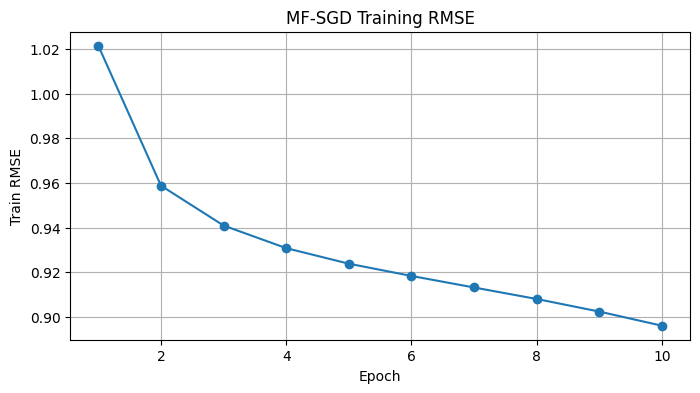

In [360]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(mf_sgd_model["history"]) + 1), mf_sgd_model["history"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train RMSE")
plt.title("MF-SGD Training RMSE")
plt.grid(True)
plt.show()

Função de predição

In [361]:
def predict_mf_sgd(model, user_id, item_id):
    u_idx = user_to_index[user_id]
    i_idx = item_to_index[item_id]

    pred = (
        model["mu"]
        + model["bu"][u_idx]
        + model["bi"][i_idx]
        + np.dot(model["P"][u_idx], model["Q"][i_idx])
    )

    pred = max(1.0, min(5.0, pred))
    return float(pred)

Função de recomendação top-K com MF-SGD

In [362]:
def recommend_mf_sgd(user_id, model, k=10):
    candidates = get_candidates(user_id, all_items, train_items_by_user)
    
    scored_items = []
    for item_id in candidates:
        score = predict_mf_sgd(model, user_id, item_id)
        scored_items.append((item_id, score))
    
    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return [int(item_id) for item_id, _ in ranked_items[:k]]

Teste rápido de recomendação

In [363]:
example_user = eligible_users[0]
example_recs_mf = recommend_mf_sgd(example_user, mf_sgd_model, k=10)

print("User:", example_user)
print("Top-10 MF-SGD item ids:", example_recs_mf)

items[items["item_id"].isin(example_recs_mf)][["item_id", "title"]]

User: 1
Top-10 MF-SGD item ids: [408, 320, 318, 657, 483, 603, 480, 313, 64, 302]


,item_id,title
63,64,"Shawshank Redemption, The (1994)"
301,302,L.A. Confidential (1997)
312,313,Titanic (1997)
317,318,Schindler's List (1993)
319,320,Paradise Lost: The Child Murders at Robin Hood...
407,408,"Close Shave, A (1995)"
479,480,North by Northwest (1959)
482,483,Casablanca (1942)
602,603,Rear Window (1954)
656,657,"Manchurian Candidate, The (1962)"


Avaliação do MF-SGD

In [364]:
mf_sgd_results = []

for user_id in eligible_users:
    recommended = recommend_mf_sgd(user_id, mf_sgd_model, k=TOP_K)
    relevant = relevant_items_by_user[user_id]

    recall = recall_at_k(recommended, relevant, k=TOP_K)
    ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
    diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

    mf_sgd_results.append({
        "user_id": int(user_id),
        "method": "mf_sgd",
        "top_k": recommended,
        "recall@10": recall,
        "ndcg@10": ndcg,
        "diversity@10": diversity
    })

mf_sgd_results_df = pd.DataFrame(mf_sgd_results)
mf_sgd_results_df.head()

,user_id,method,top_k,recall@10,ndcg@10,diversity@10
0,1,mf_sgd,"[408, 320, 318, 657, 483, 603, 480, 313, 64, 302]",0.029412,0.066254,0.801274
1,2,mf_sgd,"[114, 408, 318, 12, 603, 64, 169, 320, 134, 657]",0.000000,0.000000,0.839113
2,3,mf_sgd,"[114, 483, 408, 178, 480, 603, 515, 134, 50, 357]",0.000000,0.000000,0.767430
3,4,mf_sgd,"[12, 14, 22, 23, 50, 64, 89, 98, 100, 114]",0.500000,0.237198,0.736874
4,5,mf_sgd,"[114, 603, 318, 178, 64, 12, 134, 169, 320, 483]",0.083333,0.069431,0.802734


Médias do MF-SGD

In [365]:
mf_sgd_results_df[["recall@10", "ndcg@10", "diversity@10"]].mean()

recall@10       0.040602
ndcg@10         0.064472
diversity@10    0.787231
dtype: float64

Comparação direta com popularity

In [366]:
comparison_df = pd.DataFrame([
    {
        "method": "popularity",
        "recall@10": results_df["recall@10"].mean(),
        "ndcg@10": results_df["ndcg@10"].mean(),
        "diversity@10": results_df["diversity@10"].mean()
    },
    {
        "method": "mf_sgd",
        "recall@10": mf_sgd_results_df["recall@10"].mean(),
        "ndcg@10": mf_sgd_results_df["ndcg@10"].mean(),
        "diversity@10": mf_sgd_results_df["diversity@10"].mean()
    }
])

comparison_df

,method,recall@10,ndcg@10,diversity@10
0,popularity,0.138766,0.178276,0.752100
1,mf_sgd,0.040602,0.064472,0.787231


Guardar logs JSONL do MF-SGD

In [367]:
with open("logs/mf_sgd_eval.jsonl", "w", encoding="utf-8") as f:
    for row in mf_sgd_results:
        log_entry = {
            "user_id": row["user_id"],
            "method": row["method"],
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "k": TOP_K,
                "d": mf_sgd_model["params"]["d"],
                "lr": mf_sgd_model["params"]["lr"],
                "reg": mf_sgd_model["params"]["reg"],
                "epochs": mf_sgd_model["params"]["epochs"]
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/mf_sgd_eval.jsonl")

with open("logs/mf_sgd_eval.jsonl", "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().strip())

Ficheiro criado: logs/mf_sgd_eval.jsonl
{"user_id": 1, "method": "mf_sgd", "top_k": [408, 320, 318, 657, 483, 603, 480, 313, 64, 302], "metrics": {"recall@10": 0.029411764705882353, "ndcg@10": 0.06625422345438903, "diversity@10": 0.8012743531768736}, "hyperparameters": {"k": 10, "d": 20, "lr": 0.01, "reg": 0.05, "epochs": 10}}
{"user_id": 2, "method": "mf_sgd", "top_k": [114, 408, 318, 12, 603, 64, 169, 320, 134, 657], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.8391130652206982}, "hyperparameters": {"k": 10, "d": 20, "lr": 0.01, "reg": 0.05, "epochs": 10}}
{"user_id": 3, "method": "mf_sgd", "top_k": [114, 483, 408, 178, 480, 603, 515, 134, 50, 357], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.767429800413905}, "hyperparameters": {"k": 10, "d": 20, "lr": 0.01, "reg": 0.05, "epochs": 10}}


In [368]:
example_user = eligible_users[0]
candidates = get_candidates(example_user, all_items, train_items_by_user)

sample_scores = []
for item_id in candidates[:20]:
    sample_scores.append({
        "item_id": item_id,
        "title": items.loc[items["item_id"] == item_id, "title"].values[0],
        "score": predict_mf_sgd(mf_sgd_model, example_user, item_id)
    })

pd.DataFrame(sample_scores).sort_values("score", ascending=False).head(10)

,item_id,title,score
13,64,"Shawshank Redemption, The (1994)",4.423374
3,8,Babe (1995),4.043279
8,32,Crumb (1994),3.954288
0,1,Toy Story (1995),3.935001
11,58,Quiz Show (1994),3.815350
2,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,3.790304
7,31,Crimson Tide (1995),3.777544
19,82,Jurassic Park (1993),3.766624
4,20,Angels and Insects (1995),3.724373
1,4,Get Shorty (1995),3.684199


In [369]:
def compute_rmse(model, data):
    errors = []
    for u_idx, i_idx, rating in data:
        user_id = index_to_user[u_idx]
        item_id = index_to_item[i_idx]
        pred = predict_mf_sgd(model, user_id, item_id)
        errors.append((rating - pred) ** 2)
    return float(np.sqrt(np.mean(errors)))

train_rmse = compute_rmse(mf_sgd_model, train_data)
test_rmse = compute_rmse(mf_sgd_model, test_data)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.8831529910683023
Test RMSE: 0.9366581250364446


MF-SGD achieved reasonable RMSE on train/test, but poor top-K ranking performance compared to the popularity baseline. This supports the idea that optimizing squared rating prediction does not necessarily optimize ranking quality.

## MF-ALS

In [370]:
from collections import defaultdict

user_ratings_train = defaultdict(list)
item_ratings_train = defaultdict(list)

for u_idx, i_idx, rating in train_data:
    user_ratings_train[u_idx].append((i_idx, rating))
    item_ratings_train[i_idx].append((u_idx, rating))

print("Exemplo user ratings:", list(user_ratings_train.items())[:1])
print("Exemplo item ratings:", list(item_ratings_train.items())[:1])

Exemplo user ratings: [(806, [(1410, 1.0), (101, 4.0), (180, 5.0), (384, 4.0), (623, 3.0), (1088, 4.0), (469, 5.0), (404, 4.0), (819, 3.0), (126, 3.0), (90, 5.0), (1443, 3.0), (1090, 3.0), (141, 3.0), (624, 3.0), (49, 5.0), (514, 4.0), (153, 2.0), (841, 4.0), (203, 4.0), (549, 5.0), (698, 4.0), (94, 4.0), (509, 5.0), (704, 4.0), (415, 3.0), (464, 4.0), (482, 5.0), (540, 4.0), (526, 5.0), (629, 4.0), (120, 4.0), (470, 4.0), (621, 3.0), (135, 5.0), (229, 4.0), (418, 5.0), (67, 4.0), (575, 4.0), (416, 3.0), (143, 4.0), (1412, 2.0), (420, 3.0), (484, 5.0), (78, 5.0), (251, 4.0), (205, 2.0), (226, 4.0), (403, 3.0), (98, 5.0), (490, 5.0), (379, 4.0), (1408, 4.0), (522, 3.0), (472, 3.0), (431, 5.0), (1137, 5.0), (545, 4.0), (583, 4.0), (738, 4.0), (299, 5.0), (81, 4.0), (385, 4.0), (604, 3.0), (678, 4.0), (88, 4.0), (419, 3.0), (142, 4.0), (595, 4.0), (70, 5.0), (842, 2.0), (541, 5.0), (257, 3.0), (434, 3.0), (372, 4.0), (72, 3.0), (1062, 4.0), (587, 5.0), (380, 2.0), (483, 4.0), (448, 5.0), 

In [371]:
def train_mf_als(
    train_data,
    user_ratings_train,
    item_ratings_train,
    n_users,
    n_items,
    d=20,
    reg=0.05,
    iters=8,
    random_state=42,
    verbose=True
):
    rng = np.random.default_rng(random_state)

    mu = np.mean([rating for _, _, rating in train_data])

    P = rng.normal(0, 0.1, size=(n_users, d))
    Q = rng.normal(0, 0.1, size=(n_items, d))

    bu = np.zeros(n_users)
    bi = np.zeros(n_items)

    history = []

    I_d = np.eye(d)

    for iteration in range(iters):
        # Update user factors P
        for u_idx in range(n_users):
            ratings_u = user_ratings_train.get(u_idx, [])
            if not ratings_u:
                continue

            A = reg * I_d
            b_vec = np.zeros(d)

            for i_idx, rating in ratings_u:
                qi = Q[i_idx]
                residual = rating - (mu + bu[u_idx] + bi[i_idx])
                A += np.outer(qi, qi)
                b_vec += residual * qi

            P[u_idx] = np.linalg.solve(A, b_vec)

        # Update item factors Q
        for i_idx in range(n_items):
            ratings_i = item_ratings_train.get(i_idx, [])
            if not ratings_i:
                continue

            A = reg * I_d
            b_vec = np.zeros(d)

            for u_idx, rating in ratings_i:
                pu = P[u_idx]
                residual = rating - (mu + bu[u_idx] + bi[i_idx])
                A += np.outer(pu, pu)
                b_vec += residual * pu

            Q[i_idx] = np.linalg.solve(A, b_vec)

        # Update user biases
        for u_idx in range(n_users):
            ratings_u = user_ratings_train.get(u_idx, [])
            if not ratings_u:
                continue

            numerator = 0.0
            denominator = reg

            for i_idx, rating in ratings_u:
                pred_wo_bu = mu + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])
                numerator += rating - pred_wo_bu
                denominator += 1.0

            bu[u_idx] = numerator / denominator

        # Update item biases
        for i_idx in range(n_items):
            ratings_i = item_ratings_train.get(i_idx, [])
            if not ratings_i:
                continue

            numerator = 0.0
            denominator = reg

            for u_idx, rating in ratings_i:
                pred_wo_bi = mu + bu[u_idx] + np.dot(P[u_idx], Q[i_idx])
                numerator += rating - pred_wo_bi
                denominator += 1.0

            bi[i_idx] = numerator / denominator

        # Compute train RMSE
        squared_errors = []
        for u_idx, i_idx, rating in train_data:
            pred = mu + bu[u_idx] + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])
            pred = max(1.0, min(5.0, pred))
            squared_errors.append((rating - pred) ** 2)

        rmse = float(np.sqrt(np.mean(squared_errors)))
        history.append(rmse)

        if verbose:
            print(f"ALS Iteration {iteration + 1}/{iters} - Train RMSE: {rmse:.4f}")

    return {
        "mu": mu,
        "P": P,
        "Q": Q,
        "bu": bu,
        "bi": bi,
        "history": history,
        "params": {
            "d": d,
            "reg": reg,
            "iters": iters
        }
    }

ALS Iteration 1/8 - Train RMSE: 0.7123
ALS Iteration 2/8 - Train RMSE: 0.6127
ALS Iteration 3/8 - Train RMSE: 0.5716
ALS Iteration 4/8 - Train RMSE: 0.5478
ALS Iteration 5/8 - Train RMSE: 0.5322
ALS Iteration 6/8 - Train RMSE: 0.5209
ALS Iteration 7/8 - Train RMSE: 0.5121
ALS Iteration 8/8 - Train RMSE: 0.5050


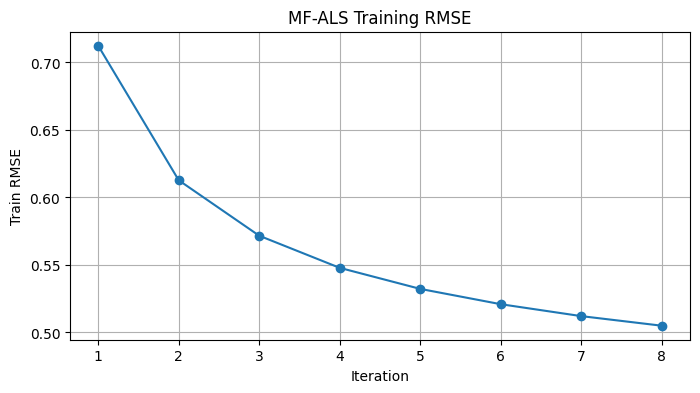

In [372]:
mf_als_model = train_mf_als(
    train_data=train_data,
    user_ratings_train=user_ratings_train,
    item_ratings_train=item_ratings_train,
    n_users=n_users,
    n_items=n_items,
    d=MF_DIM,
    reg=0.05,
    iters=ALS_ITERS,
    random_state=RANDOM_STATE,
    verbose=True
)


plt.figure(figsize=(8, 4))
plt.plot(range(1, len(mf_als_model["history"]) + 1), mf_als_model["history"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Train RMSE")
plt.title("MF-ALS Training RMSE")
plt.grid(True)
plt.show()

In [373]:
def predict_mf_als(model, user_id, item_id):
    u_idx = user_to_index[user_id]
    i_idx = item_to_index[item_id]

    pred = (
        model["mu"]
        + model["bu"][u_idx]
        + model["bi"][i_idx]
        + np.dot(model["P"][u_idx], model["Q"][i_idx])
    )

    pred = max(1.0, min(5.0, pred))
    return float(pred)

In [374]:
def recommend_mf_als(user_id, model, k=10):
    candidates = get_candidates(user_id, all_items, train_items_by_user)

    scored_items = []
    for item_id in candidates:
        score = predict_mf_als(model, user_id, item_id)
        scored_items.append((item_id, score))

    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return [int(item_id) for item_id, _ in ranked_items[:k]]

In [375]:
example_user = eligible_users[0]
example_recs_als = recommend_mf_als(example_user, mf_als_model, k=10)

print("User:", example_user)
print("Top-10 MF-ALS item ids:", example_recs_als)

items[items["item_id"].isin(example_recs_als)][["item_id", "title"]]

User: 1
Top-10 MF-ALS item ids: [110, 119, 142, 149, 181, 217, 249, 258, 262, 284]


,item_id,title
109,110,Operation Dumbo Drop (1995)
118,119,Maya Lin: A Strong Clear Vision (1994)
141,142,Bedknobs and Broomsticks (1971)
148,149,Jude (1996)
180,181,Return of the Jedi (1983)
216,217,Bram Stoker's Dracula (1992)
248,249,Austin Powers: International Man of Mystery (1...
257,258,Contact (1997)
261,262,In the Company of Men (1997)
283,284,Tin Cup (1996)


In [376]:
def compute_rmse_als(model, data):
    errors = []
    for u_idx, i_idx, rating in data:
        user_id = index_to_user[u_idx]
        item_id = index_to_item[i_idx]
        pred = predict_mf_als(model, user_id, item_id)
        errors.append((rating - pred) ** 2)
    return float(np.sqrt(np.mean(errors)))

In [377]:
train_rmse_als = compute_rmse_als(mf_als_model, train_data)
test_rmse_als = compute_rmse_als(mf_als_model, test_data)

print("MF-ALS Train RMSE:", train_rmse_als)
print("MF-ALS Test RMSE:", test_rmse_als)

MF-ALS Train RMSE: 0.504979346839837
MF-ALS Test RMSE: 1.2283251757815357


In [378]:
mf_als_results = []

for user_id in eligible_users:
    recommended = recommend_mf_als(user_id, mf_als_model, k=TOP_K)
    relevant = relevant_items_by_user[user_id]

    recall = recall_at_k(recommended, relevant, k=TOP_K)
    ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
    diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

    mf_als_results.append({
        "user_id": int(user_id),
        "method": "mf_als",
        "top_k": recommended,
        "recall@10": recall,
        "ndcg@10": ndcg,
        "diversity@10": diversity
    })

mf_als_results_df = pd.DataFrame(mf_als_results)
mf_als_results_df.head()

,user_id,method,top_k,recall@10,ndcg@10,diversity@10
0,1,mf_als,"[110, 119, 142, 149, 181, 217, 249, 258, 262, ...",0.117647,0.366801,0.852417
1,2,mf_als,"[15, 16, 33, 42, 43, 44, 49, 51, 53, 57]",0.000000,0.000000,0.702333
2,3,mf_als,"[5, 6, 10, 25, 35, 38, 40, 47, 74, 81]",0.000000,0.000000,0.693253
3,4,mf_als,"[3, 7, 10, 13, 17, 23, 24, 27, 29, 30]",0.000000,0.000000,0.786291
4,5,mf_als,"[30, 43, 48, 56, 57, 76, 78, 92, 93, 114]",0.000000,0.000000,0.694199


In [379]:
mf_als_results_df[["recall@10", "ndcg@10", "diversity@10"]].mean()

recall@10       0.016317
ndcg@10         0.029397
diversity@10    0.709417
dtype: float64

In [380]:
comparison_df = pd.DataFrame([
    {
        "method": "popularity",
        "recall@10": results_df["recall@10"].mean(),
        "ndcg@10": results_df["ndcg@10"].mean(),
        "diversity@10": results_df["diversity@10"].mean()
    },
    {
        "method": "mf_sgd",
        "recall@10": mf_sgd_results_df["recall@10"].mean(),
        "ndcg@10": mf_sgd_results_df["ndcg@10"].mean(),
        "diversity@10": mf_sgd_results_df["diversity@10"].mean()
    },
    {
        "method": "mf_als",
        "recall@10": mf_als_results_df["recall@10"].mean(),
        "ndcg@10": mf_als_results_df["ndcg@10"].mean(),
        "diversity@10": mf_als_results_df["diversity@10"].mean()
    }
])

comparison_df

,method,recall@10,ndcg@10,diversity@10
0,popularity,0.138766,0.178276,0.752100
1,mf_sgd,0.040602,0.064472,0.787231
2,mf_als,0.016317,0.029397,0.709417


In [381]:
with open("logs/mf_als_eval.jsonl", "w", encoding="utf-8") as f:
    for row in mf_als_results:
        log_entry = {
            "user_id": row["user_id"],
            "method": row["method"],
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "k": TOP_K,
                "d": mf_als_model["params"]["d"],
                "reg": mf_als_model["params"]["reg"],
                "iters": mf_als_model["params"]["iters"]
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/mf_als_eval.jsonl")

with open("logs/mf_als_eval.jsonl", "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().strip())

Ficheiro criado: logs/mf_als_eval.jsonl
{"user_id": 1, "method": "mf_als", "top_k": [110, 119, 142, 149, 181, 217, 249, 258, 262, 284], "metrics": {"recall@10": 0.11764705882352941, "ndcg@10": 0.36680070555131283, "diversity@10": 0.8524166344489926}, "hyperparameters": {"k": 10, "d": 20, "reg": 0.05, "iters": 8}}
{"user_id": 2, "method": "mf_als", "top_k": [15, 16, 33, 42, 43, 44, 49, 51, 53, 57], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.7023329082917695}, "hyperparameters": {"k": 10, "d": 20, "reg": 0.05, "iters": 8}}
{"user_id": 3, "method": "mf_als", "top_k": [5, 6, 10, 25, 35, 38, 40, 47, 74, 81], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.6932527411723959}, "hyperparameters": {"k": 10, "d": 20, "reg": 0.05, "iters": 8}}


## Pairwise LTR

In [382]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


In [383]:
def build_ltr_feature_vector(user_id, item_id, mf_model):
    u_idx = user_to_index[user_id]
    i_idx = item_to_index[item_id]

    s_mf = predict_mf_sgd(mf_model, user_id, item_id)
    bu_val = float(mf_model["bu"][u_idx])
    bi_val = float(mf_model["bi"][i_idx])
    pop_val = float(item_popularity.get(item_id, 0))

    return np.array([
        s_mf,
        bu_val,
        bi_val,
        pop_val,
        1.0
    ], dtype=float)

In [384]:
def build_pairwise_training_data(train_df, max_pairs_per_user=50, random_state=42):
    rng = np.random.default_rng(random_state)
    pairwise_examples = []

    grouped = train_df.groupby("user_id")

    for user_id, user_ratings in grouped:
        positives = user_ratings[user_ratings["rating"] >= 4]["item_id"].tolist()
        negatives = user_ratings[user_ratings["rating"] < 4]["item_id"].tolist()

        if len(positives) == 0 or len(negatives) == 0:
            continue

        possible_pairs = [(i_pos, i_neg) for i_pos in positives for i_neg in negatives]

        if len(possible_pairs) > max_pairs_per_user:
            sampled_indices = rng.choice(len(possible_pairs), size=max_pairs_per_user, replace=False)
            selected_pairs = [possible_pairs[idx] for idx in sampled_indices]
        else:
            selected_pairs = possible_pairs

        for i_pos, i_neg in selected_pairs:
            pairwise_examples.append((int(user_id), int(i_pos), int(i_neg)))

    return pairwise_examples

In [385]:
pairwise_train_examples = build_pairwise_training_data(
    train_df=train_df,
    max_pairs_per_user=50,
    random_state=RANDOM_STATE
)

print("Número de pares de treino:", len(pairwise_train_examples))
print("Exemplo:", pairwise_train_examples[:5])

Número de pares de treino: 46409
Exemplo: [(1, 191, 17), (1, 198, 252), (1, 22, 122), (1, 47, 97), (1, 55, 140)]


In [386]:
def train_pairwise_ltr(
    pairwise_examples,
    mf_model,
    epochs=5,
    lr=0.01,
    reg=0.001,
    random_state=42,
    verbose=True
):
    rng = np.random.default_rng(random_state)

    n_features = 5
    phi = np.zeros(n_features, dtype=float)

    history = []
    examples = pairwise_examples.copy()

    for epoch in range(epochs):
        rng.shuffle(examples)

        total_loss = 0.0

        for user_id, i_pos, i_neg in examples:
            f_pos = build_ltr_feature_vector(user_id, i_pos, mf_model)
            f_neg = build_ltr_feature_vector(user_id, i_neg, mf_model)

            delta_f = f_pos - f_neg
            score = np.dot(phi, delta_f)

            prob = sigmoid(score)
            loss = -np.log(max(prob, 1e-12))
            total_loss += loss

            grad = (prob - 1.0) * delta_f + reg * phi
            phi -= lr * grad

        avg_loss = total_loss / len(examples)
        history.append(avg_loss)

        if verbose:
            print(f"LTR Epoch {epoch + 1}/{epochs} - Avg Pairwise Loss: {avg_loss:.6f}")

    return {
        "phi": phi,
        "history": history,
        "params": {
            "epochs": epochs,
            "lr": lr,
            "reg": reg
        }
    }

In [387]:
pairwise_ltr_model = train_pairwise_ltr(
    pairwise_examples=pairwise_train_examples,
    mf_model=mf_sgd_model,
    epochs=5,
    lr=0.01,
    reg=0.001,
    random_state=RANDOM_STATE,
    verbose=True
)

LTR Epoch 1/5 - Avg Pairwise Loss: 7.165658
LTR Epoch 2/5 - Avg Pairwise Loss: 6.761164
LTR Epoch 3/5 - Avg Pairwise Loss: 6.727525
LTR Epoch 4/5 - Avg Pairwise Loss: 6.644766
LTR Epoch 5/5 - Avg Pairwise Loss: 6.633230


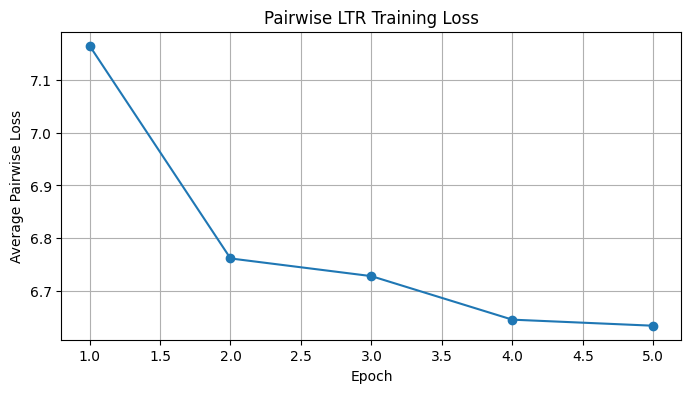

In [388]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pairwise_ltr_model["history"]) + 1), pairwise_ltr_model["history"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Pairwise Loss")
plt.title("Pairwise LTR Training Loss")
plt.grid(True)
plt.show()

In [389]:
def predict_pairwise_ltr(user_id, item_id, ltr_model, mf_model):
    features = build_ltr_feature_vector(user_id, item_id, mf_model)
    score = np.dot(ltr_model["phi"], features)
    return float(score)

In [390]:
def recommend_pairwise_ltr(user_id, ltr_model, mf_model, k=10):
    candidates = get_candidates(user_id, all_items, train_items_by_user)

    scored_items = []
    for item_id in candidates:
        score = predict_pairwise_ltr(user_id, item_id, ltr_model, mf_model)
        scored_items.append((item_id, score))

    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return [int(item_id) for item_id, _ in ranked_items[:k]]

In [391]:
example_user = eligible_users[0]
example_recs_ltr = recommend_pairwise_ltr(
    user_id=example_user,
    ltr_model=pairwise_ltr_model,
    mf_model=mf_sgd_model,
    k=10
)

print("User:", example_user)
print("Top-10 Pairwise LTR item ids:", example_recs_ltr)

items[items["item_id"].isin(example_recs_ltr)][["item_id", "title"]]

User: 1
Top-10 Pairwise LTR item ids: [100, 181, 258, 286, 288, 1, 294, 300, 237, 313]


,item_id,title
0,1,Toy Story (1995)
99,100,Fargo (1996)
180,181,Return of the Jedi (1983)
236,237,Jerry Maguire (1996)
257,258,Contact (1997)
285,286,"English Patient, The (1996)"
287,288,Scream (1996)
293,294,Liar Liar (1997)
299,300,Air Force One (1997)
312,313,Titanic (1997)


In [392]:
pairwise_ltr_results = []

for user_id in eligible_users:
    recommended = recommend_pairwise_ltr(
        user_id=user_id,
        ltr_model=pairwise_ltr_model,
        mf_model=mf_sgd_model,
        k=TOP_K
    )
    relevant = relevant_items_by_user[user_id]

    recall = recall_at_k(recommended, relevant, k=TOP_K)
    ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
    diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

    pairwise_ltr_results.append({
        "user_id": int(user_id),
        "method": "pairwise_ltr",
        "top_k": recommended,
        "recall@10": recall,
        "ndcg@10": ndcg,
        "diversity@10": diversity
    })

pairwise_ltr_results_df = pd.DataFrame(pairwise_ltr_results)
pairwise_ltr_results_df.head()

,user_id,method,top_k,recall@10,ndcg@10,diversity@10
0,1,pairwise_ltr,"[100, 181, 258, 286, 288, 1, 294, 300, 237, 313]",0.117647,0.547398,0.791491
1,2,pairwise_ltr,"[181, 98, 174, 56, 121, 7, 172, 173, 117, 222]",0.000000,0.000000,0.613086
2,3,pairwise_ltr,"[50, 100, 181, 286, 127, 294, 1, 98, 174, 56]",0.333333,0.234639,0.770950
3,4,pairwise_ltr,"[50, 100, 181, 286, 127, 1, 98, 174, 56, 121]",0.500000,0.613147,0.725466
4,5,pairwise_ltr,"[258, 286, 288, 127, 294, 174, 300, 56, 7, 237]",0.083333,0.078398,0.783726


In [393]:
pairwise_ltr_results_df[["recall@10", "ndcg@10", "diversity@10"]].mean()

recall@10       0.137577
ndcg@10         0.184589
diversity@10    0.749704
dtype: float64

In [394]:
comparison_df = pd.DataFrame([
    {
        "method": "popularity",
        "recall@10": results_df["recall@10"].mean(),
        "ndcg@10": results_df["ndcg@10"].mean(),
        "diversity@10": results_df["diversity@10"].mean()
    },
    {
        "method": "mf_sgd",
        "recall@10": mf_sgd_results_df["recall@10"].mean(),
        "ndcg@10": mf_sgd_results_df["ndcg@10"].mean(),
        "diversity@10": mf_sgd_results_df["diversity@10"].mean()
    },
    {
        "method": "mf_als",
        "recall@10": mf_als_results_df["recall@10"].mean(),
        "ndcg@10": mf_als_results_df["ndcg@10"].mean(),
        "diversity@10": mf_als_results_df["diversity@10"].mean()
    },
    {
        "method": "pairwise_ltr",
        "recall@10": pairwise_ltr_results_df["recall@10"].mean(),
        "ndcg@10": pairwise_ltr_results_df["ndcg@10"].mean(),
        "diversity@10": pairwise_ltr_results_df["diversity@10"].mean()
    }
])

comparison_df

,method,recall@10,ndcg@10,diversity@10
0,popularity,0.138766,0.178276,0.752100
1,mf_sgd,0.040602,0.064472,0.787231
2,mf_als,0.016317,0.029397,0.709417
3,pairwise_ltr,0.137577,0.184589,0.749704


In [395]:
with open("logs/pairwise_ltr_eval.jsonl", "w", encoding="utf-8") as f:
    for row in pairwise_ltr_results:
        log_entry = {
            "user_id": row["user_id"],
            "method": row["method"],
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "k": TOP_K,
                "epochs": pairwise_ltr_model["params"]["epochs"],
                "lr": pairwise_ltr_model["params"]["lr"],
                "reg": pairwise_ltr_model["params"]["reg"],
                "max_pairs_per_user": 50
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/pairwise_ltr_eval.jsonl")

Ficheiro criado: logs/pairwise_ltr_eval.jsonl


In [396]:
with open("logs/pairwise_ltr_eval.jsonl", "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().strip())

{"user_id": 1, "method": "pairwise_ltr", "top_k": [100, 181, 258, 286, 288, 1, 294, 300, 237, 313], "metrics": {"recall@10": 0.11764705882352941, "ndcg@10": 0.5473983622993502, "diversity@10": 0.7914912521185643}, "hyperparameters": {"k": 10, "epochs": 5, "lr": 0.01, "reg": 0.001, "max_pairs_per_user": 50}}
{"user_id": 2, "method": "pairwise_ltr", "top_k": [181, 98, 174, 56, 121, 7, 172, 173, 117, 222], "metrics": {"recall@10": 0.0, "ndcg@10": 0.0, "diversity@10": 0.6130857220128889}, "hyperparameters": {"k": 10, "epochs": 5, "lr": 0.01, "reg": 0.001, "max_pairs_per_user": 50}}
{"user_id": 3, "method": "pairwise_ltr", "top_k": [50, 100, 181, 286, 127, 294, 1, 98, 174, 56], "metrics": {"recall@10": 0.3333333333333333, "ndcg@10": 0.23463936301137822, "diversity@10": 0.7709495353397355}, "hyperparameters": {"k": 10, "epochs": 5, "lr": 0.01, "reg": 0.001, "max_pairs_per_user": 50}}


## MMR
1. Função para obter top-M candidatos do ranker base

Para MF-SGD

In [397]:
def get_top_m_candidates_mf_sgd(user_id, model, m=80):
    candidates = get_candidates(user_id, all_items, train_items_by_user)

    scored_items = []
    for item_id in candidates:
        score = predict_mf_sgd(model, user_id, item_id)
        scored_items.append((item_id, score))

    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return ranked_items[:m]

Para Pairwise LTR

In [398]:
def get_top_m_candidates_ltr(user_id, ltr_model, mf_model, m=80):
    candidates = get_candidates(user_id, all_items, train_items_by_user)

    scored_items = []
    for item_id in candidates:
        score = predict_pairwise_ltr(user_id, item_id, ltr_model, mf_model)
        scored_items.append((item_id, score))

    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return ranked_items[:m]

In [399]:
def item_similarity_by_genre(item_a, item_b):
    vec_a = item_genre_vectors.get(item_a)
    vec_b = item_genre_vectors.get(item_b)

    if vec_a is None or vec_b is None:
        return 0.0

    return cosine_similarity(vec_a, vec_b)

In [400]:
def mmr_rerank(scored_candidates, k=10, alpha=0.1):
    selected = []
    selected_ids = set()

    candidate_dict = {int(item_id): float(score) for item_id, score in scored_candidates}

    while len(selected) < k and len(selected) < len(scored_candidates):
        best_item = None
        best_mmr_score = -float("inf")

        for item_id, rel_score in scored_candidates:
            item_id = int(item_id)

            if item_id in selected_ids:
                continue

            if len(selected) == 0:
                mmr_score = rel_score
            else:
                max_sim = max(
                    item_similarity_by_genre(item_id, selected_item)
                    for selected_item in selected
                )
                mmr_score = (1 - alpha) * rel_score - alpha * max_sim

            if mmr_score > best_mmr_score:
                best_mmr_score = mmr_score
                best_item = item_id

        if best_item is None:
            break

        selected.append(best_item)
        selected_ids.add(best_item)

    return selected

In [401]:
example_user = eligible_users[0]
top_m_mf = get_top_m_candidates_mf_sgd(example_user, mf_sgd_model, m=TOP_M)

mmr_recs_mf_01 = mmr_rerank(top_m_mf, k=TOP_K, alpha=0.1)
mmr_recs_mf_04 = mmr_rerank(top_m_mf, k=TOP_K, alpha=0.4)
mmr_recs_mf_07 = mmr_rerank(top_m_mf, k=TOP_K, alpha=0.7)

print("User:", example_user)
print("MF-SGD + MMR alpha=0.1:", mmr_recs_mf_01)
print("MF-SGD + MMR alpha=0.4:", mmr_recs_mf_04)
print("MF-SGD + MMR alpha=0.7:", mmr_recs_mf_07)

User: 1
MF-SGD + MMR alpha=0.1: [408, 320, 318, 657, 603, 313, 483, 480, 474, 64]
MF-SGD + MMR alpha=0.4: [408, 320, 318, 493, 488, 661, 694, 530, 302, 474]
MF-SGD + MMR alpha=0.7: [408, 320, 318, 493, 488, 661, 694, 530, 100, 474]


In [402]:
alphas = [0.1, 0.4, 0.7]
mmr_mf_results = []

for alpha in alphas:
    for user_id in eligible_users:
        top_m_candidates = get_top_m_candidates_mf_sgd(user_id, mf_sgd_model, m=TOP_M)
        recommended = mmr_rerank(top_m_candidates, k=TOP_K, alpha=alpha)
        relevant = relevant_items_by_user[user_id]

        recall = recall_at_k(recommended, relevant, k=TOP_K)
        ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
        diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

        mmr_mf_results.append({
            "user_id": int(user_id),
            "method": "mmr_mf_sgd",
            "alpha": alpha,
            "top_k": recommended,
            "recall@10": recall,
            "ndcg@10": ndcg,
            "diversity@10": diversity
        })

mmr_mf_results_df = pd.DataFrame(mmr_mf_results)
mmr_mf_results_df.head()

,user_id,method,alpha,top_k,recall@10,ndcg@10,diversity@10
0,1,mmr_mf_sgd,0.1,"[408, 320, 318, 657, 603, 313, 483, 480, 474, 64]",0.029412,0.063621,0.826790
1,2,mmr_mf_sgd,0.1,"[114, 318, 12, 408, 320, 603, 64, 169, 657, 483]",0.000000,0.000000,0.846074
2,3,mmr_mf_sgd,0.1,"[114, 483, 480, 408, 178, 603, 50, 515, 657, 127]",0.000000,0.000000,0.813332
3,4,mmr_mf_sgd,0.1,"[12, 14, 89, 114, 174, 251, 320, 493, 661, 22]",0.000000,0.000000,0.981856
4,5,mmr_mf_sgd,0.1,"[114, 603, 318, 320, 178, 174, 12, 169, 64, 134]",0.166667,0.147829,0.859368


In [403]:
mmr_mf_summary_df = (
    mmr_mf_results_df
    .groupby("alpha")[["recall@10", "ndcg@10", "diversity@10"]]
    .mean()
    .reset_index()
)

mmr_mf_summary_df

,alpha,recall@10,ndcg@10,diversity@10
0,0.1,0.038300,0.064304,0.841606
1,0.4,0.037519,0.062131,0.953546
2,0.7,0.038584,0.063340,0.958097


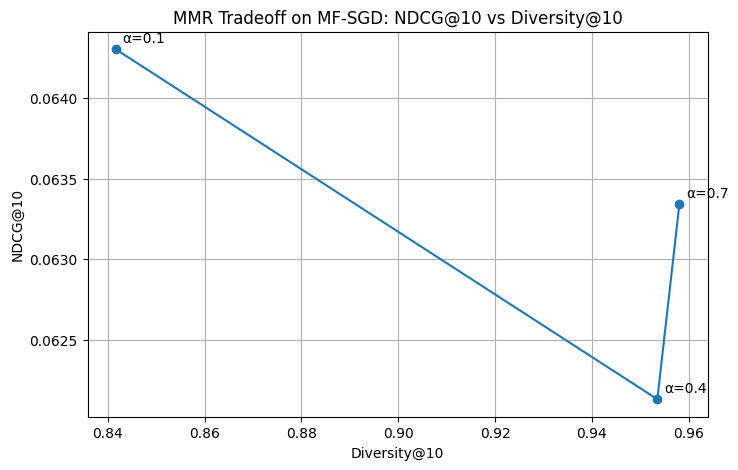

In [404]:
plt.figure(figsize=(8, 5))
plt.plot(
    mmr_mf_summary_df["diversity@10"],
    mmr_mf_summary_df["ndcg@10"],
    marker="o"
)

for _, row in mmr_mf_summary_df.iterrows():
    plt.annotate(
        f"α={row['alpha']}",
        (row["diversity@10"], row["ndcg@10"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel("Diversity@10")
plt.ylabel("NDCG@10")
plt.title("MMR Tradeoff on MF-SGD: NDCG@10 vs Diversity@10")
plt.grid(True)
plt.show()

In [405]:
with open("logs/mmr_mf_sgd_eval.jsonl", "w", encoding="utf-8") as f:
    for row in mmr_mf_results:
        log_entry = {
            "user_id": row["user_id"],
            "method": row["method"],
            "alpha": float(row["alpha"]),
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "M": TOP_M,
                "K": TOP_K,
                "alpha": float(row["alpha"]),
                "base_ranker": "mf_sgd"
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/mmr_mf_sgd_eval.jsonl")

Ficheiro criado: logs/mmr_mf_sgd_eval.jsonl


In [406]:
mmr_ltr_results = []

for alpha in alphas:
    for user_id in eligible_users:
        top_m_candidates = get_top_m_candidates_ltr(
            user_id=user_id,
            ltr_model=pairwise_ltr_model,
            mf_model=mf_sgd_model,
            m=TOP_M
        )
        recommended = mmr_rerank(top_m_candidates, k=TOP_K, alpha=alpha)
        relevant = relevant_items_by_user[user_id]

        recall = recall_at_k(recommended, relevant, k=TOP_K)
        ndcg = ndcg_at_k(recommended, relevant, k=TOP_K)
        diversity = diversity_at_k(recommended, item_genre_vectors, k=TOP_K)

        mmr_ltr_results.append({
            "user_id": int(user_id),
            "method": "mmr_pairwise_ltr",
            "alpha": alpha,
            "top_k": recommended,
            "recall@10": recall,
            "ndcg@10": ndcg,
            "diversity@10": diversity
        })

mmr_ltr_results_df = pd.DataFrame(mmr_ltr_results)
mmr_ltr_results_df.head()

,user_id,method,alpha,top_k,recall@10,ndcg@10,diversity@10
0,1,mmr_pairwise_ltr,0.1,"[100, 181, 258, 286, 288, 1, 294, 300, 237, 313]",0.117647,0.547398,0.791491
1,2,mmr_pairwise_ltr,0.1,"[181, 98, 174, 56, 121, 7, 172, 173, 117, 222]",0.000000,0.000000,0.613086
2,3,mmr_pairwise_ltr,0.1,"[50, 100, 181, 286, 127, 294, 1, 98, 174, 56]",0.333333,0.234639,0.770950
3,4,mmr_pairwise_ltr,0.1,"[50, 100, 181, 286, 127, 1, 98, 174, 56, 121]",0.500000,0.613147,0.725466
4,5,mmr_pairwise_ltr,0.1,"[258, 286, 288, 127, 294, 174, 300, 56, 7, 237]",0.083333,0.078398,0.783726


In [407]:
mmr_ltr_summary_df = (
    mmr_ltr_results_df
    .groupby("alpha")[["recall@10", "ndcg@10", "diversity@10"]]
    .mean()
    .reset_index()
)

mmr_ltr_summary_df

,alpha,recall@10,ndcg@10,diversity@10
0,0.1,0.137577,0.184589,0.749704
1,0.4,0.137577,0.184436,0.749789
2,0.7,0.138688,0.184734,0.749863


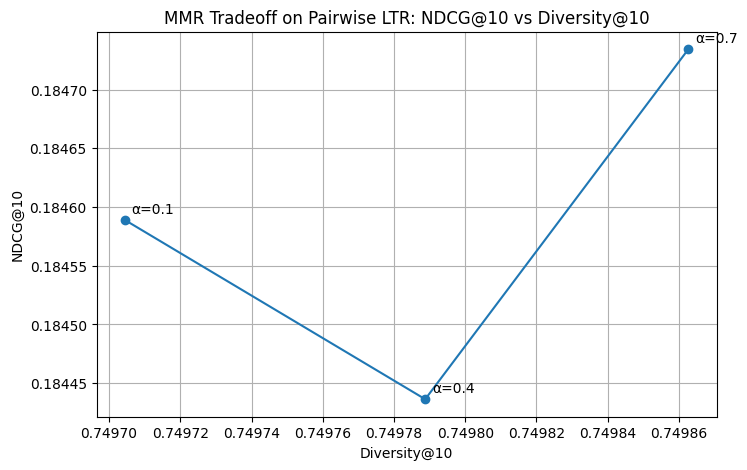

In [408]:
plt.figure(figsize=(8, 5))
plt.plot(
    mmr_ltr_summary_df["diversity@10"],
    mmr_ltr_summary_df["ndcg@10"],
    marker="o"
)

for _, row in mmr_ltr_summary_df.iterrows():
    plt.annotate(
        f"α={row['alpha']}",
        (row["diversity@10"], row["ndcg@10"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel("Diversity@10")
plt.ylabel("NDCG@10")
plt.title("MMR Tradeoff on Pairwise LTR: NDCG@10 vs Diversity@10")
plt.grid(True)
plt.show()

In [409]:
with open("logs/mmr_pairwise_ltr_eval.jsonl", "w", encoding="utf-8") as f:
    for row in mmr_ltr_results:
        log_entry = {
            "user_id": row["user_id"],
            "method": row["method"],
            "alpha": float(row["alpha"]),
            "top_k": [int(x) for x in row["top_k"]],
            "metrics": {
                "recall@10": None if row["recall@10"] is None else float(row["recall@10"]),
                "ndcg@10": None if row["ndcg@10"] is None else float(row["ndcg@10"]),
                "diversity@10": float(row["diversity@10"])
            },
            "hyperparameters": {
                "M": TOP_M,
                "K": TOP_K,
                "alpha": float(row["alpha"]),
                "base_ranker": "pairwise_ltr"
            }
        }
        f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/mmr_pairwise_ltr_eval.jsonl")

Ficheiro criado: logs/mmr_pairwise_ltr_eval.jsonl


In [410]:
mmr_mf_summary_df

,alpha,recall@10,ndcg@10,diversity@10
0,0.1,0.038300,0.064304,0.841606
1,0.4,0.037519,0.062131,0.953546
2,0.7,0.038584,0.063340,0.958097


In [411]:
mmr_ltr_summary_df

,alpha,recall@10,ndcg@10,diversity@10
0,0.1,0.137577,0.184589,0.749704
1,0.4,0.137577,0.184436,0.749789
2,0.7,0.138688,0.184734,0.749863


## EMA

In [412]:
def normalize_vector(vec):
    norm = np.linalg.norm(vec)
    if norm == 0:
        return vec
    return vec / norm

def get_initial_user_state(user_id, mf_model):
    u_idx = user_to_index[user_id]
    return normalize_vector(mf_model["P"][u_idx].copy())


def ema_update_user_state(current_state, item_id, mf_model, rho=0.1):
    i_idx = item_to_index[item_id]
    item_vector = mf_model["Q"][i_idx]

    updated_state = (1 - rho) * current_state + rho * item_vector
    updated_state = normalize_vector(updated_state)

    return updated_state


def session_adjusted_score(user_id, item_id, session_state, ltr_model, mf_model, beta=0.3):
    base_score = predict_pairwise_ltr(user_id, item_id, ltr_model, mf_model)

    i_idx = item_to_index[item_id]
    item_vector = normalize_vector(mf_model["Q"][i_idx])

    session_affinity = float(np.dot(session_state, item_vector))

    return (1 - beta) * base_score + beta * session_affinity


def recommend_session_ltr(user_id, session_state, ltr_model, mf_model, seen_in_session=None, k=10, beta=0.3):
    if seen_in_session is None:
        seen_in_session = set()

    candidates = get_candidates(user_id, all_items, train_items_by_user)
    candidates = [item_id for item_id in candidates if item_id not in seen_in_session]

    scored_items = []
    for item_id in candidates:
        score = session_adjusted_score(
            user_id=user_id,
            item_id=item_id,
            session_state=session_state,
            ltr_model=ltr_model,
            mf_model=mf_model,
            beta=beta
        )
        scored_items.append((item_id, score))

    ranked_items = sorted(scored_items, key=lambda x: x[1], reverse=True)
    return [int(item_id) for item_id, _ in ranked_items[:k]]

def simulate_user_choice(recommended_items, session_state, mf_model):
    best_item = None
    best_score = -float("inf")

    for item_id in recommended_items:
        i_idx = item_to_index[item_id]
        item_vector = normalize_vector(mf_model["Q"][i_idx])
        affinity = float(np.dot(session_state, item_vector))

        if affinity > best_score:
            best_score = affinity
            best_item = item_id

    return int(best_item)

In [413]:
def run_user_session(
    user_id,
    ltr_model,
    mf_model,
    rounds=5,
    k=10,
    rho=0.1,
    beta=0.3
):
    session_state = get_initial_user_state(user_id, mf_model)
    seen_in_session = set()
    session_logs = []

    for round_idx in range(1, rounds + 1):
        recommended = recommend_session_ltr(
            user_id=user_id,
            session_state=session_state,
            ltr_model=ltr_model,
            mf_model=mf_model,
            seen_in_session=seen_in_session,
            k=k,
            beta=beta
        )

        chosen_item = simulate_user_choice(recommended, session_state, mf_model)

        session_logs.append({
            "round": round_idx,
            "recommended_items": recommended,
            "recommended_titles": items[items["item_id"].isin(recommended)]["title"].tolist(),
            "chosen_item": int(chosen_item),
            "chosen_title": items.loc[items["item_id"] == chosen_item, "title"].values[0]
        })

        seen_in_session.add(chosen_item)
        session_state = ema_update_user_state(
            current_state=session_state,
            item_id=chosen_item,
            mf_model=mf_model,
            rho=rho
        )

    return {
        "user_id": int(user_id),
        "rho": rho,
        "beta": beta,
        "rounds": rounds,
        "logs": session_logs
    }

In [414]:
session_users = eligible_users[:3]
session_users

[np.int64(1), np.int64(2), np.int64(3)]

In [415]:
session_results = []

for user_id in session_users:
    session_result = run_user_session(
        user_id=user_id,
        ltr_model=pairwise_ltr_model,
        mf_model=mf_sgd_model,
        rounds=5,
        k=TOP_K,
        rho=0.1,
        beta=0.3
    )
    session_results.append(session_result)

print("Número de sessões:", len(session_results))

Número de sessões: 3


In [416]:
def print_session_summary(session_result):
    print(f"User ID: {session_result['user_id']}")
    print(f"rho: {session_result['rho']}, beta: {session_result['beta']}")
    print("-" * 80)

    for log in session_result["logs"]:
        print(f"Round {log['round']}")
        print("Recommended item ids:", log["recommended_items"])
        print("Chosen item:", log["chosen_item"], "-", log["chosen_title"])
        print("-" * 80)

In [417]:
for session_result in session_results:
    print_session_summary(session_result)
    print("\n")

User ID: 1
rho: 0.1, beta: 0.3
--------------------------------------------------------------------------------
Round 1
Recommended item ids: [100, 181, 258, 286, 288, 1, 300, 294, 237, 313]
Chosen item: 258 - Contact (1997)
--------------------------------------------------------------------------------
Round 2
Recommended item ids: [100, 181, 286, 288, 1, 300, 294, 237, 313, 204]
Chosen item: 313 - Titanic (1997)
--------------------------------------------------------------------------------
Round 3
Recommended item ids: [100, 181, 286, 288, 1, 300, 294, 237, 204, 318]
Chosen item: 181 - Return of the Jedi (1983)
--------------------------------------------------------------------------------
Round 4
Recommended item ids: [100, 286, 288, 1, 300, 294, 237, 204, 318, 302]
Chosen item: 302 - L.A. Confidential (1997)
--------------------------------------------------------------------------------
Round 5
Recommended item ids: [100, 286, 288, 1, 300, 294, 237, 204, 318, 64]
Chosen item: 

In [418]:
session_rows = []

for session_result in session_results:
    for log in session_result["logs"]:
        session_rows.append({
            "user_id": session_result["user_id"],
            "round": log["round"],
            "chosen_item": log["chosen_item"],
            "chosen_title": log["chosen_title"]
        })

session_summary_df = pd.DataFrame(session_rows)
session_summary_df

,user_id,round,chosen_item,chosen_title
0,1,1,258,Contact (1997)
1,1,2,313,Titanic (1997)
2,1,3,181,Return of the Jedi (1983)
3,1,4,302,L.A. Confidential (1997)
4,1,5,1,Toy Story (1995)
5,2,1,181,Return of the Jedi (1983)
6,2,2,168,Monty Python and the Holy Grail (1974)
7,2,3,174,Raiders of the Lost Ark (1981)
8,2,4,172,"Empire Strikes Back, The (1980)"
9,2,5,318,Schindler's List (1993)


In [419]:
session_recommendation_rows = []

for session_result in session_results:
    for log in session_result["logs"]:
        session_recommendation_rows.append({
            "user_id": session_result["user_id"],
            "round": log["round"],
            "recommended_items": log["recommended_items"],
            "chosen_item": log["chosen_item"],
            "chosen_title": log["chosen_title"]
        })

session_recommendations_df = pd.DataFrame(session_recommendation_rows)
session_recommendations_df

,user_id,round,recommended_items,chosen_item,chosen_title
0,1,1,"[100, 181, 258, 286, 288, 1, 300, 294, 237, 313]",258,Contact (1997)
1,1,2,"[100, 181, 286, 288, 1, 300, 294, 237, 313, 204]",313,Titanic (1997)
2,1,3,"[100, 181, 286, 288, 1, 300, 294, 237, 204, 318]",181,Return of the Jedi (1983)
3,1,4,"[100, 286, 288, 1, 300, 294, 237, 204, 318, 302]",302,L.A. Confidential (1997)
4,1,5,"[100, 286, 288, 1, 300, 294, 237, 204, 318, 64]",1,Toy Story (1995)
5,2,1,"[181, 98, 174, 56, 121, 7, 172, 173, 117, 222]",181,Return of the Jedi (1983)
6,2,2,"[98, 174, 56, 121, 7, 172, 173, 117, 222, 168]",168,Monty Python and the Holy Grail (1974)
7,2,3,"[98, 174, 56, 121, 7, 172, 173, 117, 222, 204]",174,Raiders of the Lost Ark (1981)
8,2,4,"[98, 56, 121, 7, 172, 173, 117, 222, 204, 79]",172,"Empire Strikes Back, The (1980)"
9,2,5,"[98, 56, 121, 7, 173, 117, 222, 204, 79, 318]",318,Schindler's List (1993)


In [420]:
with open("logs/session_ema_eval.jsonl", "w", encoding="utf-8") as f:
    for session_result in session_results:
        for log in session_result["logs"]:
            log_entry = {
                "user_id": int(session_result["user_id"]),
                "method": "session_ema_pairwise_ltr",
                "round": int(log["round"]),
                "recommended_items": [int(x) for x in log["recommended_items"]],
                "chosen_item": int(log["chosen_item"]),
                "chosen_title": log["chosen_title"],
                "hyperparameters": {
                    "rho": float(session_result["rho"]),
                    "beta": float(session_result["beta"]),
                    "k": TOP_K
                }
            }
            f.write(json.dumps(log_entry) + "\n")

print("Ficheiro criado: logs/session_ema_eval.jsonl")

Ficheiro criado: logs/session_ema_eval.jsonl


In [421]:
with open("logs/session_ema_eval.jsonl", "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())

{"user_id": 1, "method": "session_ema_pairwise_ltr", "round": 1, "recommended_items": [100, 181, 258, 286, 288, 1, 300, 294, 237, 313], "chosen_item": 258, "chosen_title": "Contact (1997)", "hyperparameters": {"rho": 0.1, "beta": 0.3, "k": 10}}
{"user_id": 1, "method": "session_ema_pairwise_ltr", "round": 2, "recommended_items": [100, 181, 286, 288, 1, 300, 294, 237, 313, 204], "chosen_item": 313, "chosen_title": "Titanic (1997)", "hyperparameters": {"rho": 0.1, "beta": 0.3, "k": 10}}
{"user_id": 1, "method": "session_ema_pairwise_ltr", "round": 3, "recommended_items": [100, 181, 286, 288, 1, 300, 294, 237, 204, 318], "chosen_item": 181, "chosen_title": "Return of the Jedi (1983)", "hyperparameters": {"rho": 0.1, "beta": 0.3, "k": 10}}
{"user_id": 1, "method": "session_ema_pairwise_ltr", "round": 4, "recommended_items": [100, 286, 288, 1, 300, 294, 237, 204, 318, 302], "chosen_item": 302, "chosen_title": "L.A. Confidential (1997)", "hyperparameters": {"rho": 0.1, "beta": 0.3, "k": 10}}

In [422]:
session_results_rho_comparison = []

for rho_value in [0.1, 0.3]:
    for user_id in session_users:
        session_result = run_user_session(
            user_id=user_id,
            ltr_model=pairwise_ltr_model,
            mf_model=mf_sgd_model,
            rounds=5,
            k=TOP_K,
            rho=rho_value,
            beta=0.3
        )
        session_results_rho_comparison.append(session_result)

print("Sessões rho comparison:", len(session_results_rho_comparison))

Sessões rho comparison: 6
